# Final Project

This final project can be collaborative. The maximum members of a group is 3. You can also work by yourself. Please respect the academic integrity. **Remember: if you get caught on cheating, you get F.**

## A Introduction to the competition

<img src="news-sexisme-EN.jpg" alt="drawing" width="380"/>

Sexism is a growing problem online. It can inflict harm on women who are targeted, make online spaces inaccessible and unwelcoming, and perpetuate social asymmetries and injustices. Automated tools are now widely deployed to find, and assess sexist content at scale but most only give classifications for generic, high-level categories, with no further explanation. Flagging what is sexist content and also explaining why it is sexist improves interpretability, trust and understanding of the decisions that automated tools use, empowering both users and moderators.

This project is based on SemEval 2023 - Task 10 - Explainable Detection of Online Sexism (EDOS). [Here](https://codalab.lisn.upsaclay.fr/competitions/7124#learn_the_details-overview) you can find a detailed introduction to this task.

You only need to complete **TASK A - Binary Sexism Detection: a two-class (or binary) classification where systems have to predict whether a post is sexist or not sexist**. To cut down training time, we only use a subset of the original dataset (5k out of 20k). The dataset can be found in the same folder. 

Different from our previous homework, this competition gives you great flexibility (and very few hints). You can freely determine every component of your workflow, including but not limited to:
-  **Preprocessing the input text**: You may decide how to clean or transform the text. For example, removing emojis or URLs, lowercasing, removing stopwords, applying stemming or lemmatization, correcting spelling, or performing tokenization and sentence segmentation.
-  **Feature extraction and encoding**: You can choose any method to convert text into numerical representations, such as TF-IDF, Bag-of-Words, N-grams, Word2Vec, GloVe, FastText, contextual embeddings (e.g., BERT, RoBERTa, or other transformer-based models), Part-of-Speech (POS) tagging, dependency-based features, sentiment or emotion features, readability metrics, or even embeddings or features generated by large language models (LLMs).
-  **Data augmentation and enrichment**: You may expand or balance your dataset by incorporating other related corpora or using techniques like synonym replacement, random deletion/insertion, or LLM-assisted augmentation (e.g., generating paraphrased or synthetic examples to improve model robustness).
-  **Model selection**: You are free to experiment with different models — from traditional machine learning algorithms (e.g., Logistic Regression, SVM, Random Forest, XGBoost) to deep learning architectures (e.g., CNNs, RNNs, Transformers), or even hybrid/ensemble approaches that combine multiple models or leverage LLM-generated predictions or reasoning.

## Requirements
-  **Input**: the text for each instance.
-  **Output**: the binary label for each instance.
-  **Feature engineering**: use at least 2 different methods to extract features and encode text into numerical values. You may explore both traditional and AI-assisted techniques. Data augmentation is optional.
-  **Model selection**: implement with at least 3 different models and compare their performance.
-  **Evaluation**: create a dataframe with rows indicating feature+model and columns indicating Precision (P), Recall (R) and F1-score (using weighted average). Your results should have at least 6 rows (2 feature engineering methods x 3 models). Report best performance with (1) your feature engineering method, and (2) the model you choose. Here is an example illustrating how the experimental results table should be presented.

| Feature + Model | Sexist (P) | Sexist (R) | Sexist (F1) | Non-Sexist (P) | Non-Sexist (R) | Non-Sexist (F1) | Weighted (P) | Weighted (R) | Weighted (F1) |
|-----------------|:----------:|:----------:|:------------:|:---------------:|:---------------:|:----------------:|:-------------:|:--------------:|:---------------:|
| TF-IDF + Logistic Regression | ... | ... | ... | ... | ... | ... | ... | ... | ... |

- **Format of the report**: add explainations for each step (you can add markdown cells). At the end of the report, write a summary for each sections: 
    - Data Preprocessing
    - Feature Engineering
    - Model Selection and Architecture
    - Training and Validation
    - Evaluation and Results
    - Use of Generative AI (if you use)

## Rules 
Violations will result in 0 points in the grade: 
-   `Rule 1 - No test set leakage`: You must not use any instance from the test set during training, feature engineering, or model selection.
-   `Rule 2 - Responsible AI use`: You may use generative AI, but you must clearly document how it was used. If you have used genAI, include a section titled “Use of Generative AI” describing:
    -   What parts of the project you used AI for
    -   What was implemented manually vs. with AI assistance

## Grading

The performance should be only evaluated on the test set (a total of 1086 instances). Please split original dataset into train set and test set. The test set should NEVER be used in the training process. The evaluation metric is a combination of precision, recall, and f1-score (use `classification_report` in sklearn). 

The total points are 10.0. Each team will compete with other teams in the class on their best performance. Points will be deducted if not following the requirements above. 

If ALL the requirements are met:
- Top 25\% teams: 10.0 points.
- Top 25\% - 50\% teams: 8.5 points.
- Top 50\% - 75\% teams: 7.0 points.
- Top 75\% - 100\% teams: 6.0 points.

If your best performance reaches **0.82** or above (weighted F1-score) and follows all the requirements and rules, you will also get full points (10.0 points). 

## Submission
Similar as homework, submit both a PDF and .ipynb version of the report including: 
- code and experimental results with details explained
- combined results table, report and best performance
- a summary at the end of the report (please follow the format above)

Missing any part of the above requirements will result in point deductions.

The due date is **May 8, Friday by 11:59pm**.

In [3]:
# start your code here

#imports
import pandas as pd
import numpy as np
#import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
import matplotlib.colors as colors
import matplotlib.pyplot as plt

size: 21116
size of df_train: 16772
                 rewire_id                                               text  \
0  sexism2022_english-9609  In Nigeria, if you rape a woman, the men rape ...   

        label  split  
0  not sexist  train  
                                                text       label
0  In Nigeria, if you rape a woman, the men rape ...  not sexist
1                            Then, she's a keeper. 😉  not sexist
2  This is like the Metallica video where the poo...  not sexist
3                                             woman?  not sexist
4                     I bet she wished she had a gun  not sexist
                                                   text label
2642  Chicks dig scars, maybe you should do a cool o...     1
2469  The only thing strong independent women need i...     1
                                                text label
0  In Nigeria, if you rape a woman, the men rape ...     0
1                            Then, she's a keeper. 😉     0
2 

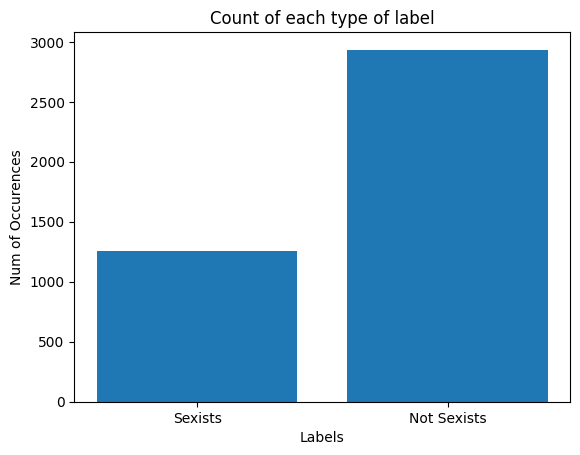

                                                text label
6  [USER] Leg day is easy. Hot girls who wear min...     1
                                                text label
0  In Nigeria, if you rape a woman, the men rape ...     0


2000

In [4]:
#looking at Data
df = pd.read_csv('edos_labelled_data.csv')

#print(df.head(5))
print(f"size: {df.size}")

#feels like incorrect size
df_train = df[df['split'] == 'train']
print(f"size of df_train: {df_train.size}")

print(df_train.head(1))
#drop unhelpful columns
df_train.drop('rewire_id', axis=1, inplace=True)
df_train.drop('split', axis=1, inplace=True)
print(df_train.head(5))

#replace label so its 1 and 0
df_train['label'] = df_train['label'].replace({'sexist': 1, 'not sexist': 0})
print(df_train.sort_values(by=['label'], ascending=False).head(2))
print(df_train.head(5))

#check number of each type
counts = [len(df_train[df_train['label'] == 1]), len(df_train[df_train['label'] == 0]) ]

plt.bar(x= ['Sexists', 'Not Sexists'], height=counts)
plt.xlabel('Labels')
plt.ylabel('Num of Occurences')
plt.title('Count of each type of label')
plt.show()

#Split data so equal amount of Sexists and 
# Not Sexists Points

df_train_s = df_train.loc[(df_train['label']==1)]
df_train_ns = df_train.loc[(df_train['label']==0)]

print(df_train_s.head(1))
print(df_train_ns.head(1))
#df_no_default_downsampled = resample(df_no_default, replace=False, n_samples=1000, random_state=42 )
df_train_s_downsample = resample(df_train_s, replace= False, n_samples=1000)
df_train_ns_downsample = resample(df_train_ns, replace= False, n_samples=1000)

df_balance = pd.concat([df_train_s_downsample, df_train_ns_downsample])
len(df_balance)

In [12]:
#Data Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')




[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\05jth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\05jth\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\05jth\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:

def clean_df(df):
    cleanedData = []
    lemma = WordNetLemmatizer()
    #could test altering stop words
    swords = set(stopwords.words("english")) - {'his', 'her', 'he', 'she', 'their'}

    #clean links
    for text in df_balance["text"]:
        text = re.sub(r'http\S+', '', text)

        #cleaning everything except alphabetical, numerical, and "" (to maintain sarcasm)
        text = re.sub("[^a-zA-Z0-9\"]", " ", text)

        #tokenizing and lemmanizing such that words are in their simpler form
        text = nltk.word_tokenize(text.lower())
        text = [lemma.lemmatize(word) for word in text]

        #removing nuetral words from text
        text = [word for word in text if word not in swords]
        text = " ".join(text)

        cleanedData.append(text)


    for i in range(0,5):
        print(cleanedData[i],end="\n\n")

    return cleanedData


In [ ]:
#clean the balanced data
cleaned_balance = clean_df(df_balance)



reason 5 attention whore looking validation favor free stuff

dumb woman today ask divorced collecting huge alimony check

ghost stupid bitch delete block her everything join local fascist organization read everything enrico corradini julius evola corneliu codreanu

bet she eats his pussy

layin pipe lmfao pussy looking milk toast mother fucker coudln lay pipe his name wa roto rooter



## Experimental Results

(A table detailed model performance on the test set with at least 6 rows. Report the best performance.)


## Project Summary
### 1. Data Preprocessing


### 2. Feature Engineering
 

### 3. Model Selection and Architecture


### 4. Training and Validation


### 5. Evaluation and Results


### 6. Use of Generative AI (if you use)